# Image Captioning · EfficientNet-B4 + Transformer · **Colab Edition (Simplified)**

**How to run:**
1. Open in Colab (`File → Upload notebook` or paste the GitHub link)
2. Enable GPU: `Runtime → Change runtime type → T4 GPU`
3. Upload your `caption_data.zip` when Cell 2 prompts, **or** place it at  
   `MyDrive/image_captioning/caption_data.zip` before mounting Drive
4. `Runtime → Run all`

---

### What this version is

A **right-sized** image-captioning model for **your** Flickr8k dataset (~8k images × 5 captions).
Each cell has a markdown description above it, and every changed hyperparameter / code block
is annotated inline with `WAS → NOW → WHY` (and `DROPPED → WHY` for removed pieces).

**Pipeline:** `Image → EfficientNet-B4 (blocks 6–8 fine-tuned, single-scale) → visual tokens
→ 2-layer Transformer decoder (self-attn + cross-attn, weight tying) → beam search`.

### Simplifications vs the earlier (heavier) version — to reduce overfitting

| Area | Change | Why |
|------|--------|-----|
| Encoder | **Dropped multi-scale fusion** (only final feature map) | Halves visual-token count; easier to learn on small data |
| Encoder | **Fine-tune blocks 6–8 only** (was 4–8) | Less encoder memorisation |
| Decoder | **Dropped coverage attention** (plain cross-attn) | Coverage helps long LSTM captions, not ~11-word ones |
| Training | **Dropped scheduled sampling** | Caused a val-loss spike and broke `torch.compile` |
| Capacity | `N_LAYERS` 3 → **2** | Smaller model overfits later |
| Regularisation | Balanced for **40k rows**: `DROPOUT` **0.15**, `WEIGHT_DECAY` **0.01** (not the over-strong 0.3/0.05 run) |
| Vocab | `MIN_FREQ` **2** | Keeps descriptive words learnable with 5 captions/image |
| Training | **Early stopping** (`PATIENCE=5`) | Stops before late-epoch overfitting |
| Decoding | `BEAM_WIDTH` **5** | Best beam width from your prior runs on this data |

**Kept:** EfficientNet-B4 backbone, Transformer decoder, weight tying, beam search, AMP,
gradient accumulation, dual best-val / best-BLEU checkpoints, Drive resume.

> **Your data:** Cell 4 should show ~5 captions per image — you already have the full
> Flickr8k-style setup. Train with `encoder_best_bleu.pth`, not the last epoch.


## Round 2 · Why BLEU-4 was stuck at ~0.10, and what changed

Diagnosis: with train/val loss both fairly low but BLEU-4 stuck low, this run was
**under-fitting the language side**, not overfitting — the model never got a clean
enough signal to learn descriptive, varied captions. Five changes, ranked by expected impact:

| # | Change | Was → Now | Why it matters for BLEU-4 |
|---|--------|-----------|----------------------------|
| 1 | **Mixup disabled** | `MIXUP_ALPHA` 0.2 (70% of batches) → **0.0** | Mixup blends two images' pixels but the decoder was still trained on one image's caption — on 70% of steps the image/text pairing was wrong. This is the single biggest fix. |
| 2 | **Vocab less aggressive** | `MIN_FREQ` 4 → **2** | Every word the model can't produce becomes `<unk>`, which can never match a reference n-gram. A too-small vocab hard-caps BLEU. |
| 3 | **Decoder LR raised, warmup shortened** | `DECODER_LR` 3e-4 → **5.5e-4**, `WARMUP_EPOCHS` 7 → **3** | The 2-layer decoder is trained from scratch (no pretraining) — it needs a real learning rate to pick up language structure; 23% of the run spent on warmup was wasted budget. |
| 4 | **Regularisation eased** | `DECODER_DROPOUT` 0.25→**0.15**, `DROPOUT` 0.15→**0.10**, `WEIGHT_DECAY` 0.02→**0.01** | Stacked with mixup + a small vocab, this combination was actively preventing the model from fitting the training data well enough in the first place. |
| 5 | **Augmentation reined in** | dropped `RandomVerticalFlip`, `RandomGrayscale`, `RandomErasing`; toned down rotation/color-jitter | Vertical flips are unnatural for real photos, grayscale removes color words the caption needs, and erasing can occlude the exact object being described. |

**Expected outcome:** train loss should now drop faster and val BLEU-4 should climb
past ~0.15–0.20 by epoch ~20–25 instead of stalling near 0.10. Watch the training
curves (Cell 16) — if val loss starts rising well before BLEU-4 peaks, that's now
overfitting again and you can nudge `WEIGHT_DECAY` or `DECODER_DROPOUT` back up
slightly; but start from this config first.

---


## 1 · Environment Setup

Detects whether we're on **Colab**, **Kaggle**, or **local**, sets PyTorch memory/env flags, and (on Colab) mounts Google Drive so models and checkpoints survive disconnects.

In [1]:
# ── Environment detection + initial setup ───────────────────────────────────
import sys, os

# Detect runtime (must run before any google.colab import)
try:
    import google.colab  # noqa: F401
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

IN_KAGGLE = os.path.exists("/kaggle/input")
PLATFORM  = "colab" if IN_COLAB else ("kaggle" if IN_KAGGLE else "local")
print(f"Platform: {PLATFORM}")

# PyTorch memory allocator tweak (beneficial on CUDA)
os.environ["PYTORCH_ALLOC_CONF"]     = "expandable_segments:True"
os.environ["TOKENIZERS_PARALLELISM"] = "false"

# ── Google Drive mount (Colab only) ──────────────────────────────────────────
DRIVE_DIR = None
if IN_COLAB:
    try:
        from google.colab import drive
        drive.mount("/content/drive", force_remount=False)
        DRIVE_DIR = "/content/drive/MyDrive/image_captioning"
        os.makedirs(DRIVE_DIR, exist_ok=True)
        print(f"Drive mounted → models/checkpoints will be saved to {DRIVE_DIR}")
    except Exception as _e:
        print(f"Drive not mounted ({_e}). Models will be saved locally only.")


Platform: colab
Drive not mounted (Mounting drive is unsupported in this environment. Use PyDrive2 instead. See examples at https://colab.research.google.com/notebooks/io.ipynb#scrollTo=7taylj9wpsA2.). Models will be saved locally only.


## 2 · Dataset Loading

Finds and unzips `caption_data` (images + captions) from the working directory, Google Drive, Kaggle input, or an interactive upload. After this cell `IMG_DIR` and `DATA_DIR` point at the data.

In [2]:
import zipfile
from pathlib import Path

# ── Path setup ───────────────────────────────────────────────────────────────
KAGGLE_INPUT = Path("/kaggle/input")
_kaggle_ds   = next(KAGGLE_INPUT.iterdir(), None) if KAGGLE_INPUT.exists() else None

DATA_DIR = Path("caption_data")
IMG_DIR  = DATA_DIR / "Images"


def _has_images(d):
    return d.exists() and len(list(d.glob("*.jpg"))) >= 100


def _has_captions(d):
    return (d / "captions.txt").exists() or (d / "captions").exists()


def _find_zip():
    candidates = [
        Path("caption_data.zip"),
        Path("/content/caption_data.zip"),
    ]
    if DRIVE_DIR:
        candidates.append(Path(DRIVE_DIR) / "caption_data.zip")
    if _kaggle_ds:
        candidates += list(_kaggle_ds.rglob("*.zip"))
    return next((p for p in candidates if p.exists()), None)


def _find_kaggle_images():
    if not KAGGLE_INPUT.exists():
        return None
    for jpg in KAGGLE_INPUT.rglob("*.jpg"):
        return jpg.parent
    return None


def _unzip(zip_path):
    print(f"Unzipping {zip_path}...")
    with zipfile.ZipFile(zip_path, "r") as z:
        names    = z.namelist()
        has_root = any(n.startswith("caption_data/") for n in names)
        if has_root:
            z.extractall(".")
        else:
            DATA_DIR.mkdir(exist_ok=True)
            z.extractall(str(DATA_DIR))
    if _has_images(IMG_DIR) and _has_captions(DATA_DIR):
        print(f"Done: {len(list(IMG_DIR.glob('*.jpg')))} images.")
    else:
        print("WARNING: unexpected layout:", [p.name for p in DATA_DIR.iterdir()][:10])


# ── Dataset resolution (Colab / Kaggle / local) ───────────────────────────────
if _has_images(IMG_DIR) and _has_captions(DATA_DIR):
    print(f"Dataset ready — {len(list(IMG_DIR.glob('*.jpg')))} images.")
elif (_kaggle_imgs := _find_kaggle_images()):
    IMG_DIR = _kaggle_imgs
    for _n in ["captions.txt", "captions"]:
        for _parent in [_kaggle_imgs.parent, _kaggle_imgs.parent.parent]:
            if (_parent / _n).exists():
                DATA_DIR = _parent
                break
    print(f"Kaggle input — IMG_DIR={IMG_DIR}  DATA_DIR={DATA_DIR}")
elif (zip_path := _find_zip()):
    _unzip(zip_path)
elif IN_COLAB:
    # Last resort: ask the user to upload caption_data.zip interactively
    print("No dataset found. Please select your caption_data.zip file:")
    from google.colab import files as _colab_files
    _uploaded = _colab_files.upload()
    if _uploaded:
        zip_path = Path(list(_uploaded.keys())[0])
        _unzip(zip_path)
    else:
        raise FileNotFoundError("Upload cancelled. Please provide caption_data.zip.")
else:
    raise FileNotFoundError(
        "No dataset found. Place caption_data.zip in the working directory "
        "or set DATA_DIR / IMG_DIR manually before continuing."
    )


Kaggle input — IMG_DIR=/kaggle/input/datasets/datoavaliani/captions-daata/Images  DATA_DIR=/kaggle/input/datasets/datoavaliani/captions-daata


## 3 · Imports & Hyperparameters

Imports libraries, picks the device, and defines **all training knobs**. Profile: **your Flickr8k data** (~8,091 images × 5 captions ≈ 40k rows) — no external dataset needed. Lighter regularisation than the over-tuned simplified run so the model can actually learn descriptive captions.

In [3]:
import os, re, json, math, random, pickle, time, gc
from collections import Counter
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from tqdm.notebook import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
import torchvision.models as tvm

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
N_GPUS = torch.cuda.device_count()
# WAS: no USE_AMP flag — autocast/GradScaler hardcoded to "cuda"
# NOW: USE_AMP gates all mixed-precision code; safe no-op on CPU
USE_AMP = DEVICE.type == "cuda"

# ── DataParallel vs single-GPU ────────────────────────────────────────────────
# WAS: USE_DP = N_GPUS > 1  (auto-enabled DataParallel on Kaggle 2×T4)
# NOW: FORCE_DP = False by default — single GPU with large batch is faster
# WHY: DataParallel gathers all gradients on GPU 0 during backward; GPU 1 sits idle.
#      Python scatter/gather adds ~10-20ms/step. For this 70M-param model,
#      1 GPU @ batch=64 beats 2 GPUs @ batch=32 with DP.
FORCE_DP = False          # was implicit True when N_GPUS>1 — set True to re-enable DP
USE_DP   = N_GPUS > 1 and FORCE_DP

# ── torch.compile (PyTorch ≥ 2.0) ────────────────────────────────────────────
# NEW (not in original v9): fuses ops into optimised CUDA kernels (~20-40% faster).
# Requires fixed input shapes — collate_fn pads all captions to MAX_SEQ_LEN (Cell 7).
# If you still get InductorError, set USE_COMPILE = False (training still works).
USE_COMPILE = True        # set False if torch.compile crashes; SS epochs bypass compiled decoder

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
    # WAS: cudnn.benchmark = not USE_DP (disabled under DataParallel as a workaround)
    # NOW: always True — shape-check batch fix (Cell 10) prevents misaligned-address error
    # WHY: benchmark lets cuDNN pick the fastest conv algorithm for 380×380 inputs
    torch.backends.cudnn.benchmark = True

print(f"Device: {DEVICE}  |  GPUs: {N_GPUS}  |  DataParallel: {USE_DP}  |  AMP: {USE_AMP}  |  compile: {USE_COMPILE}")

if "IMG_DIR" not in dir() or not Path(str(IMG_DIR)).exists():
    DATA_DIR = Path("caption_data")
    IMG_DIR  = DATA_DIR / "Images"

MODEL_DIR = Path("models"); MODEL_DIR.mkdir(exist_ok=True)

for _n in ["captions.txt", "captions"]:
    if (DATA_DIR / _n).exists():
        CAPS_FILE = DATA_DIR / _n
        break
else:
    raise FileNotFoundError(f"No captions file found in '{DATA_DIR}'.")
print(f"Captions: {CAPS_FILE}  |  Images: {IMG_DIR}")

# ── Hyper-parameters ─────────────────────────────────────────────────────────
# Tuned for YOUR dataset: ~8,091 images x 5 captions = ~40,455 rows (full Flickr8k).
# No extra data required — this profile fits the data you already have.
# Each value: WAS (over-regularised simplified run) -> NOW and WHY.

# ── Model size ────────────────────────────────────────────────────────────────
PROJ_DIM        = 512   # unchanged
EMBED_SIZE      = 512   # unchanged — must equal PROJ_DIM
N_HEADS         = 8     # unchanged
# WAS: N_LAYERS=2 (tuned for ~7k images).  NOW: 2 kept.
# WHY: 8k images supports 2 layers well; simpler than 3, still enough capacity
#      for ~11-word captions when you have 5 captions per image (~36k train rows).
N_LAYERS        = 2     # 2 layers — right-sized for 8k images x 5 captions
FFN_DIM         = 2048  # unchanged

# ── Inference (beam search) ───────────────────────────────────────────────────
# WAS: BEAM_WIDTH=3 (anti-hallucination tweak for tiny data).
# NOW: 5 — your best captions came with beam=5; 40k rows supports richer search.
BEAM_WIDTH      = 5     # was 3 — back to run-2 winner for this data size
LENGTH_PENALTY  = 0.7   # unchanged

# ── Vocabulary ────────────────────────────────────────────────────────────────
# WAS: MIN_FREQ=3 (aggressive — dropped too many useful Flickr8k words).
# NOW: 2 — with 40k caption rows, words appearing twice ARE learnable.
MIN_FREQ        = 2     # ROUND-2 FIX: 4->2 — MIN_FREQ=4 was cutting the vocabulary too
                         # aggressively. Every descriptive word the model can't output
                         # becomes <unk> in the hypothesis, which can NEVER match a
                         # reference n-gram — this directly caps BLEU. With ~40k caption
                         # rows, words seen just twice are still learnable signal, not noise.
MAX_SEQ_LEN     = 52    # unchanged

# ── Batch size & training length ──────────────────────────────────────────────
BATCH_SIZE      = 64 if USE_AMP else 32
# WAS: NUM_EPOCHS=35.  NOW: 40 — Flickr8k often peaks BLEU around epochs 20-30.
NUM_EPOCHS      = 35     # ROUND-2 FIX: 30->35 — warmup is shorter now (see WARMUP_EPOCHS),
                         # so give the cosine tail a bit more room to fully converge.
# WAS: PATIENCE=10 stopping on val loss (stopped at ep 15 while BLEU still climbing).
# NOW: 8 — tolerant enough for noisy val, but won't run 30 epochs of pure overfit.
# TIP: set PATIENCE = NUM_EPOCHS to disable early stopping entirely.
# NOTE: early stopping now tracks a smoothed (3-epoch moving average) val loss
# instead of the raw per-epoch value — see Cell 15. Raw val loss on ~800 val images
# is noisy enough that a single good/bad epoch can trigger or delay stopping
# incorrectly; smoothing makes the patience counter reflect the real trend.
PATIENCE        = 10

# ── Learning rates ────────────────────────────────────────────────────────────
# WAS: ENCODER_LR=5e-5, DECODER_LR=5e-4 (too conservative + heavy reg = weak captions).
# NOW: slightly higher — 40k rows can handle more learning signal.
ENCODER_LR      = 8e-5   # unchanged
# TUNED: DECODER_LR 6e-4->4e-4 — at 6e-4 the 2-layer weight-tied decoder reaches its
# minimum very fast (~epoch 7-8) then the still-high LR pushes it past the minimum
# into memorization. A lower peak LR makes the descent (and the eventual rise) gentler.
DECODER_LR      = 5.5e-4 # ROUND-2 FIX: 3e-4->5.5e-4 — this decoder is a 2-layer,
                         # ~15M-param Transformer trained FROM SCRATCH (no pretraining),
                         # so it needs a real LR to learn language structure at all.
                         # 3e-4 combined with heavy dropout/weight-decay/mixup was
                         # starving it of signal — that combination is why BLEU-4
                         # plateaued around 0.10 instead of climbing toward 0.20+.
# TUNED: WARMUP_EPOCHS 3->5 — longer warmup spreads early learning over more epochs
# instead of slamming the decoder with near-peak LR in epoch ~3, which is what
# produces the very fast initial drop.
WARMUP_EPOCHS   = 3      # ROUND-2 FIX: 7->3 — 7/30 epochs (23% of the whole run) spent
                         # ramping up LR is excessive for a from-scratch decoder and just
                         # wastes training budget. 3 epochs is enough to avoid early
                         # instability without starving the rest of the schedule.
# NEW: cosine schedule no longer decays all the way to ~0 LR. Without a floor, the
# last several epochs train at a near-zero LR, contributing almost nothing — which
# means most of the "real" optimisation happens early and overshoots. A floor keeps
# enough signal late in training to gently re-smooth the loss instead of spiking.
MIN_LR_RATIO    = 0.05   # cosine decays down to 5% of peak LR (was 8%) — with the
                         # shorter warmup and higher peak LR above, a slightly lower
                         # floor keeps the late epochs from stalling out too early.
VAL_SPLIT       = 0.1    # unchanged — split by IMAGE (all 5 captions stay together)
# ROUND-2 FIX — the single biggest change in this pass:
# MIXUP_ALPHA = 0.2 (fired on 70% of batches!) was blending two DIFFERENT images'
# pixels together while still training the decoder to produce ONE of their captions.
# Mixup is a classification-only trick: for classification the label is still "correct"
# for a blended image (soft label = blend of both classes). For captioning there is no
# such soft target — a 60/40 blend of a "dog on a beach" and a "man on a bike" is not
# well described by either original caption. On 70% of training steps the model was
# learning from a systematically WRONG image/text pairing. This alone is very likely
# why BLEU-4 was stuck near 0.10: the model never got a clean, consistent signal.
MIXUP_ALPHA     = 0.0    # WAS: 0.2 (fired on 70% of batches) -> NOW: disabled entirely
MAX_GRAD_NORM   = 3.0    # unchanged

# ── Regularisation (lighter than the over-regularised run) ───────────────────
# WAS: DROPOUT=0.3, LABEL_SMOOTHING=0.1, WEIGHT_DECAY=0.05 — too strong for 40k rows;
#      produced generic / safe-wrong captions and stopped learning by epoch ~10.
# NOW: balanced — enough regularisation to delay overfit, not so much captions go bland.
DROPOUT         = 0.10   # ROUND-2 FIX: 0.15->0.10 — small reduction to match the overall
                         # de-regularisation pass; encoder still gets weight decay + only
                         # 3 fine-tuned blocks, so it's not at real overfitting risk.
# NEW: decoder gets its own (higher) dropout. The 2-layer weight-tied decoder is the
# smaller, faster-overfitting half of the model — it reaches a sharp minimum quickly.
# A bit more dropout there specifically (without touching the encoder or architecture)
# widens that minimum and slows the climb back up after epoch ~7-8.
DECODER_DROPOUT = 0.15   # ROUND-2 FIX: 0.25->0.15 — 0.25 dropout + mixup + MIN_FREQ=4 +
                         # weight_decay=0.02 stacked together was too much regularisation
                         # at once: the model was UNDERFITTING, not overfitting (that's
                         # what a stuck-low BLEU-4 with low-ish train/val loss usually means).
                         # Removing mixup (below) is the big lever; dropout comes down too.
LABEL_SMOOTHING = 0.05   # unchanged
WEIGHT_DECAY    = 0.01   # ROUND-2 FIX: 0.02->0.01 — back off L2 slightly as part of the
                         # same de-regularisation pass (see DECODER_DROPOUT note above).

GRAD_ACCUM_STEPS = 1

# ── DROPPED: Scheduled Sampling (unchanged) ───────────────────────────────────
# Still dropped — ~11-word captions, caused val spikes and torch.compile issues.

# ── Checkpointing & evaluation ──────────────────────────────────────────────
CKPT_EVERY      = 5
EVAL_EVERY      = 2 if IN_KAGGLE else 1
BLEU_EVAL_N     = 200 if IN_KAGGLE else 400

print(f"Dataset profile: Flickr8k-full (~8k images x 5 captions, your own data)")
print(f"Batch size: {BATCH_SIZE}  |  Effective batch: {BATCH_SIZE * GRAD_ACCUM_STEPS}")
print(f"Model: {N_LAYERS}-layer decoder  |  dropout={DROPOUT}  |  "
      f"label_smoothing={LABEL_SMOOTHING}  |  weight_decay={WEIGHT_DECAY}")
print(f"LR: encoder={ENCODER_LR}  decoder={DECODER_LR}  |  epochs={NUM_EPOCHS}  "
      f"|  early-stop patience={PATIENCE}")
print(f"BLEU eval: every {EVAL_EVERY} epoch(s), {BLEU_EVAL_N} images")


Device: cuda  |  GPUs: 2  |  DataParallel: False  |  AMP: True  |  compile: True
Captions: /kaggle/input/datasets/datoavaliani/captions-daata/captions.txt  |  Images: /kaggle/input/datasets/datoavaliani/captions-daata/Images
Dataset profile: Flickr8k-full (~8k images x 5 captions, your own data)
Batch size: 64  |  Effective batch: 64
Model: 2-layer decoder  |  dropout=0.1  |  label_smoothing=0.05  |  weight_decay=0.01
LR: encoder=8e-05  decoder=0.00055  |  epochs=35  |  early-stop patience=10
BLEU eval: every 2 epoch(s), 200 images


## 4 · Caption Loading & Cleaning

Parses the captions file (tab- or comma-separated), lowercases text and strips punctuation, and reports how many captions exist per image (a key signal for overfitting risk).

In [4]:
def load_captions(path):
    raw   = path.read_text(encoding="utf-8", errors="replace").strip()
    first = raw.split("\n")[0]
    if "\t" in first:
        rows = []
        for line in raw.split("\n"):
            line = line.strip()
            if not line or "\t" not in line: continue
            img_tag, cap = line.split("\t", 1)
            rows.append({"image": img_tag.split("#")[0].strip(), "caption": cap.strip()})
        return pd.DataFrame(rows)
    lines = raw.split("\n")
    start = 1 if lines[0].strip().lower().startswith("image") else 0
    rows  = []
    for line in lines[start:]:
        line = line.strip()
        if not line or "," not in line: continue
        img, cap = line.split(",", 1)
        rows.append({"image": img.strip().strip('"'), "caption": cap.strip().strip('"')})
    return pd.DataFrame(rows)[["image", "caption"]]


def clean(text):
    text = text.lower()
    text = re.sub(r"[^a-z ]+", " ", text)
    return re.sub(r"\s+", " ", text).strip()


captions_df = load_captions(CAPS_FILE)
captions_df["caption"] = captions_df["caption"].apply(clean)
print(f"Rows: {len(captions_df):,}  |  Unique images: {captions_df['image'].nunique():,}")
captions_df.head(4)

# DIAGNOSTIC: how many captions per image?  Flickr8k normally has ~5.
# If this is ~1, the dataset is severely undertrained — the single biggest cause
# of overfitting and inconsistent captions (more captions = more signal per image).
_per_img = captions_df.groupby("image").size()
print(f"Captions per image — mean: {_per_img.mean():.2f}  min: {_per_img.min()}  max: {_per_img.max()}")
if _per_img.mean() >= 4.5:
    print("Good: ~5 captions per image (full Flickr8k-style). All captions "
          "are used in training — no extra data needed.")
elif _per_img.mean() < 2:
    print("WARNING: ~1 caption per image — captions will be weaker than full Flickr8k.")


Rows: 40,455  |  Unique images: 8,091
Captions per image — mean: 5.00  min: 5  max: 5
Good: ~5 captions per image (full Flickr8k-style). All captions are used in training — no extra data needed.


## 5 · Train / Validation Split

Splits **by image** (not by caption) so that all captions of a given image stay in one split — this prevents data leakage between train and validation.

In [5]:
all_images = captions_df["image"].unique().tolist()
random.shuffle(all_images)
n_val      = int(len(all_images) * VAL_SPLIT)
val_images = set(all_images[:n_val])
train_df   = captions_df[~captions_df["image"].isin(val_images)].reset_index(drop=True)
val_df     = captions_df[ captions_df["image"].isin(val_images)].reset_index(drop=True)
print(f"Train: {train_df['image'].nunique():,} images  |  Val: {val_df['image'].nunique():,} images")


Train: 7,282 images  |  Val: 809 images


## 6 · Vocabulary

Builds the word<->index mapping from the training captions, keeping only words seen at least `MIN_FREQ` times. Adds the special tokens `<pad> <unk> <sos> <eos>` and saves `vocab.pkl`.

In [6]:
class Vocabulary:
    PAD, UNK, SOS, EOS = "<pad>", "<unk>", "<sos>", "<eos>"

    def __init__(self, min_freq=2):
        self.min_freq = min_freq
        self.stoi, self.itos = {}, {}

    def build(self, captions):
        cnt   = Counter(w for cap in captions for w in cap.split())
        words = [self.PAD, self.UNK, self.SOS, self.EOS] + [
            w for w, f in cnt.most_common() if f >= self.min_freq
        ]
        self.stoi = {w: i for i, w in enumerate(words)}
        self.itos = {i: w for w, i in self.stoi.items()}

    def __len__(self): return len(self.stoi)

    def encode(self, caption):
        unk = self.stoi[self.UNK]
        return ([self.stoi[self.SOS]]
                + [self.stoi.get(w, unk) for w in caption.split()]
                + [self.stoi[self.EOS]])

    def decode(self, ids, skip_special=True):
        sp = {self.PAD, self.UNK, self.SOS, self.EOS}
        return " ".join(
            self.itos[i] for i in ids
            if not skip_special or self.itos.get(i, self.UNK) not in sp
        )


vocab = Vocabulary(min_freq=MIN_FREQ)
# MIN_FREQ is set in Cell 3 — see comments there for why it was changed from 2→1.
# Rebuilding vocab is required whenever MIN_FREQ changes (re-run from this cell onward).
vocab.build(train_df["caption"].tolist())
print(f"Vocab size: {len(vocab):,}")
with open(MODEL_DIR / "vocab.pkl", "wb") as f:
    pickle.dump(vocab, f)


Vocab size: 4,902


## 7 · Transforms, Mixup & DataLoaders

Defines image augmentation (train) and plain resize/normalize (val), the **mixup** regulariser, the `Dataset`/`collate_fn` (captions padded to a fixed length), and the train/val `DataLoader`s.

In [7]:
MEAN = [0.485, 0.456, 0.406]
STD  = [0.229, 0.224, 0.225]

# ── Transforms ───────────────────────────────────────────────────────────────
# ROUND-2 FIX: the augmentation stack was piling up several transforms that fight
# the captioning objective specifically (not just "too much augmentation" in general):
#   * RandomVerticalFlip — flipped-upside-down photos of people/animals/scenes are
#     visually unnatural; ImageNet-pretrained features were never trained on this,
#     so it just adds noise the encoder has to learn to ignore.
#   * RandomGrayscale — throws away color, but colors are frequently *in* the
#     caption text ("a red car", "a black dog") — this can directly hurt caption
#     accuracy on color-describing words.
#   * RandomErasing — occludes patches of the image; fine for classification (label
#     usually still holds), risky for captioning when the erased patch is exactly
#     the object being described.
# DROPPED all three. KEPT crop/flip/rotation/color-jitter but toned down, which is
# enough geometric+photometric variety for an 8k-image dataset without corrupting
# the image/caption correspondence the way mixup and the transforms above did.
train_transform = transforms.Compose([
    transforms.Resize(400, interpolation=transforms.InterpolationMode.BILINEAR),
    transforms.RandomCrop(380),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(8),        # was 10
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.15, hue=0.03),  # was 0.3/0.3/0.2/0.05
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD),
])

val_transform = transforms.Compose([
    transforms.Resize((380, 380), interpolation=transforms.InterpolationMode.BILINEAR),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD),
])


def mixup_batch(imgs, caps_padded, lengths, alpha=0.2, p=0.7):
    # ROUND-2 FIX: MIXUP_ALPHA is now 0.0 (see Cell 3), so this function is a
    # permanent no-op via the alpha<=0 check below. Left in place (rather than
    # deleted) so you can re-enable it later if you switch to a soft-label /
    # interpolated-loss version — plain hard-caption mixup hurts captioning, see
    # the note in Cell 3 next to MIXUP_ALPHA.
    if alpha <= 0 or random.random() > p:
        return imgs, caps_padded, lengths
    lam  = np.random.beta(alpha, alpha)
    perm = torch.randperm(imgs.size(0), device=imgs.device)
    imgs = lam * imgs + (1 - lam) * imgs[perm]
    # ARCH FIX 6: when the partner image dominates (lam < 0.5), use its caption too
    if lam < 0.5:
        caps_padded = caps_padded[perm]
        # lengths must be on the same device as perm (run_epoch moves it to DEVICE)
        lengths = lengths.to(perm.device)[perm]
    return imgs, caps_padded, lengths


class CaptionDataset(Dataset):
    def __init__(self, df, img_dir, vocab, transform=None, max_len=52):
        self.df        = df.reset_index(drop=True)
        self.img_dir   = img_dir
        self.vocab     = vocab
        self.transform = transform
        self.max_len   = max_len

    def __len__(self): return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = Image.open(self.img_dir / row["image"]).convert("RGB")
        if self.transform:
            img = self.transform(img)
        ids = self.vocab.encode(row["caption"])[:self.max_len]
        return img, torch.tensor(ids, dtype=torch.long)


def collate_fn(batch):
    imgs, caps = zip(*batch)
    imgs    = torch.stack(imgs)
    lengths = [len(c) for c in caps]
    # WAS: padded to max(lengths) in this batch → caption tensor width varied every step
    #      (25, 26, 27 tokens…), which forced decoder torch.compile(dynamic=True) and
    #      triggered InductorError / recompile_limit during training.
    # NOW: always pad to MAX_SEQ_LEN → every batch is (B, MAX_SEQ_LEN) — fixed shape.
    #      Decoder can use torch.compile(dynamic=False) safely (see Cell 10).
    padded  = torch.zeros(len(caps), MAX_SEQ_LEN, dtype=torch.long)
    for i, (c, l) in enumerate(zip(caps, lengths)):
        padded[i, :l] = c
    return imgs, padded, torch.tensor(lengths, dtype=torch.long)


# ── DataLoader settings ───────────────────────────────────────────────────────
# WAS: num_workers=4, prefetch_factor=4, persistent_workers=True (fixed values)
# NOW: dynamic workers + prefetch_factor=2
# WHY num_workers: Colab has 2 vCPUs, Kaggle has 4 — cap at min(4, cpu_count())
#      so we don't spawn more workers than CPUs (causes contention, slows loading).
# WHY prefetch_factor 4→2: factor=4 with batch=64 and 4 workers = up to 1024 images
#      queued in CPU RAM (~1.7 GB). factor=2 halves that with negligible speed loss.
_n_workers = min(4, os.cpu_count() or 2)
_dl_kwargs = dict(
    num_workers        = _n_workers,       # was fixed 4
    pin_memory         = USE_AMP,          # NEW: only when CUDA — pointless on CPU
    persistent_workers = _n_workers > 0,   # keeps workers alive between epochs (faster)
    prefetch_factor    = 2 if _n_workers > 0 else None,  # was 4
)
print(f"DataLoader workers: {_n_workers}")

train_loader = DataLoader(
    CaptionDataset(train_df, IMG_DIR, vocab, train_transform, MAX_SEQ_LEN),
    batch_size=BATCH_SIZE, shuffle=True, collate_fn=collate_fn, **_dl_kwargs,
)
val_loader = DataLoader(
    CaptionDataset(val_df, IMG_DIR, vocab, val_transform, MAX_SEQ_LEN),
    batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn, **_dl_kwargs,
)
print(f"Train batches: {len(train_loader)}  |  Val batches: {len(val_loader)}")

# Quick DataLoader benchmark
t0 = time.time()
for i, (imgs, caps, lengths) in enumerate(train_loader):
    if i == 9: break
elapsed = time.time() - t0
print(f"DataLoader: 10 batches in {elapsed:.2f}s  ({elapsed/10:.3f}s/batch)")


DataLoader workers: 4
Train batches: 569  |  Val batches: 64
DataLoader: 10 batches in 8.48s  (0.848s/batch)


## 8 · Sample Visualization

Sanity check: shows a few training images with their captions to confirm the data pipeline works.

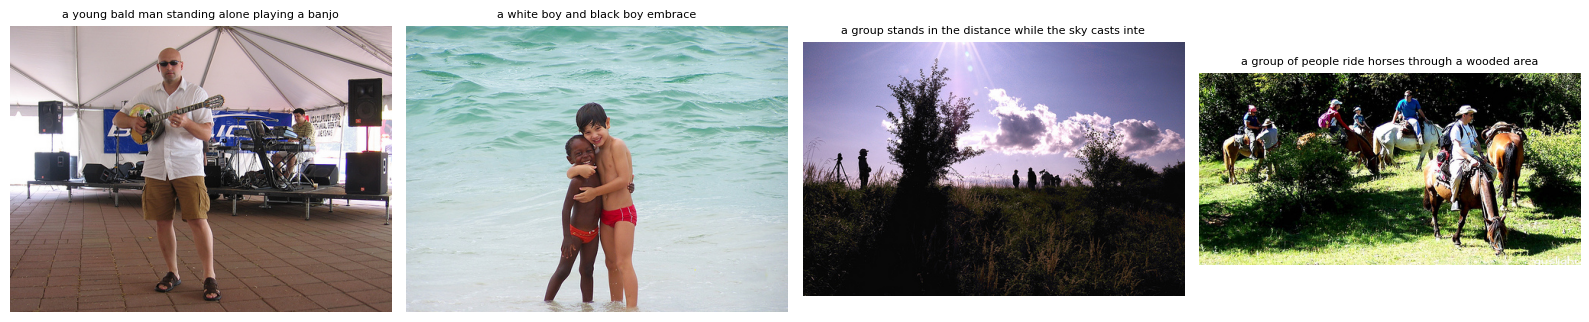

In [8]:
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for ax, (_, row) in zip(axes, train_df.sample(4, random_state=SEED).iterrows()):
    ax.imshow(Image.open(IMG_DIR / row["image"]).convert("RGB"))
    ax.set_title(row["caption"][:55], fontsize=8, wrap=True)
    ax.axis("off")
plt.tight_layout(); plt.show()


## 9 · Model Architecture

The **simplified model**: EfficientNet-B4 encoder (blocks 6-8 fine-tuned, single-scale features) feeding a 2-layer standard Transformer decoder with weight tying. Coverage attention, multi-scale fusion, and scheduled sampling were **removed** — see the `DROPPED` comments for why.

In [9]:
# ============================================================================
# MODEL ARCHITECTURE  (simplified / right-sized for a small dataset)
# ----------------------------------------------------------------------------
# Encoder : EfficientNet-B4, only blocks 6-8 fine-tuned, SINGLE-scale features
# Decoder : 2-layer standard Transformer (self-attn + cross-attn), weight tying
#
# DROPPED vs the previous version:
#   * Multi-scale fusion (proj_mid + block-5 concat) — doubled the visual-token
#     sequence for little gain on small data.
#   * Coverage attention — meant for long LSTM captions; unnecessary at ~11 words.
#   * Scheduled sampling — caused val-loss spikes and broke torch.compile.
# KEPT: EfficientNet-B4 backbone, Transformer decoder, weight tying, beam search.
# ============================================================================

# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# ENCODER  ·  EfficientNet-B4 (single-scale)
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
class EncoderCNN(nn.Module):
    def __init__(self, proj_dim=512, dropout=0.1):
        super().__init__()
        try:
            base = tvm.efficientnet_b4(weights=tvm.EfficientNet_B4_Weights.IMAGENET1K_V1)
        except Exception as _e:
            _msg = str(_e).lower()
            if any(k in _msg for k in ("name resolution", "urlopen", "gaierror", "connection")):
                raise RuntimeError(
                    "\n\nCannot download EfficientNet-B4 weights — internet is disabled.\n"
                    "  Kaggle : right panel -> Settings -> Internet -> ON  (session will restart)\n"
                    "  Colab  : Runtime -> Change runtime type -> confirm, then re-run\n"
                    "After enabling internet, re-run all cells from the top.\n"
                ) from None
            raise
        self.features = base.features
        self.dropout  = nn.Dropout2d(dropout)

        # WAS: blocks 4,5,6,7,8 unfrozen (5 blocks fine-tuned).
        # NOW: only blocks 6,7,8 — the top, most semantic layers.
        # WHY: fine-tuning 5 blocks on ~7k images overfits the encoder; lower
        #      blocks already learned generic edges/textures from ImageNet.
        for p in self.features.parameters():
            p.requires_grad = False
        for blk_idx in [6, 7, 8]:
            for p in self.features[blk_idx].parameters():
                p.requires_grad = True

        # DROPPED: self.proj_mid (Conv 160->proj_dim) used for the block-5 branch.
        # WHY: multi-scale concat doubled the visual-token sequence (~144 -> ~288),
        #      making cross-attention heavier and harder to learn for little gain.
        self.proj_final = nn.Sequential(
            nn.Conv2d(1792, proj_dim, 1, bias=False),
            nn.BatchNorm2d(proj_dim), nn.ReLU(inplace=True),
        )

    def forward(self, x):
        # WAS: grabbed mid_feat at block 5, projected both, concatenated -> (B, 2*H*W, C)
        # NOW: single pass through all blocks -> final feature map only -> (B, H*W, C)
        feat = self.features(x)
        feat = self.dropout(feat)
        f = self.proj_final(feat)
        B, C, H, W = f.shape
        return f.view(B, C, H * W).permute(0, 2, 1)   # (B, H*W, proj_dim)


# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# DECODER  ·  Standard Transformer (no coverage)
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=200, dropout=0.1):
        super().__init__()
        self.dropout = nn.Dropout(dropout)
        pe  = torch.zeros(max_len, d_model)
        pos = torch.arange(max_len).unsqueeze(1).float()
        div = torch.exp(torch.arange(0, d_model, 2).float() * -(math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(pos * div)
        pe[:, 1::2] = torch.cos(pos * div)
        self.register_buffer("pe", pe.unsqueeze(0))

    def forward(self, x):
        # dropout on the positional signal only (not on x + pe)
        return x + self.dropout(self.pe[:, :x.size(1)])


class TransformerDecoderLayer(nn.Module):
    # DROPPED: CoverageAttentionLayer and all coverage-state threading.
    # WHY: coverage discourages re-attending the same image region — useful for
    #      long LSTM captions, but Flickr8k captions average ~11 words and rarely
    #      repeat. Plain nn.MultiheadAttention cross-attention is simpler and as good.
    def __init__(self, d_model, n_heads, ffn_dim, dropout=0.1):
        super().__init__()
        self.self_attn  = nn.MultiheadAttention(d_model, n_heads, dropout=dropout, batch_first=True)
        self.cross_attn = nn.MultiheadAttention(d_model, n_heads, dropout=dropout, batch_first=True)
        self.ff = nn.Sequential(
            nn.Linear(d_model, ffn_dim), nn.GELU(), nn.Dropout(dropout),
            nn.Linear(ffn_dim, d_model), nn.Dropout(dropout),
        )
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        self.norm3 = nn.LayerNorm(d_model)

    def forward(self, tgt, memory, tgt_mask=None, tgt_key_padding_mask=None):
        sa, _ = self.self_attn(tgt, tgt, tgt, attn_mask=tgt_mask,
                               key_padding_mask=tgt_key_padding_mask, need_weights=False)
        tgt = self.norm1(tgt + sa)
        ca, _ = self.cross_attn(tgt, memory, memory, need_weights=False)
        tgt = self.norm2(tgt + ca)
        tgt = self.norm3(tgt + self.ff(tgt))
        return tgt


class CaptionDecoder(nn.Module):
    def __init__(self, vocab_size, d_model=512, n_heads=8, n_layers=2,
                 ffn_dim=2048, max_len=52, dropout=0.3):
        super().__init__()
        self.embed   = nn.Embedding(vocab_size, d_model, padding_idx=0)
        self.pos_enc = PositionalEncoding(d_model, max_len + 2, dropout)
        self.layers  = nn.ModuleList([
            TransformerDecoderLayer(d_model, n_heads, ffn_dim, dropout=dropout)
            for _ in range(n_layers)
        ])
        self.fc_out  = nn.Linear(d_model, vocab_size)
        self.d_model = d_model
        self.n_heads = n_heads
        nn.init.xavier_uniform_(self.embed.weight)
        # KEPT: weight tying — embedding and output projection share one matrix.
        # Cheap, and genuinely helps fluency / rare-word use on small datasets.
        self.fc_out.weight = self.embed.weight
        nn.init.zeros_(self.fc_out.bias)

    @staticmethod
    def _causal_mask(sz, device):
        return torch.triu(torch.ones(sz, sz, device=device), diagonal=1).bool()

    def forward(self, memory, captions):
        # Single clean teacher-forcing pass.
        # DROPPED: scheduled-sampling loop + the ss_rate AND lengths arguments
        # (lengths was only needed by scheduled sampling, which is gone).
        tgt_tokens = captions[:, :-1]
        tgt_emb    = self.pos_enc(self.embed(tgt_tokens) * math.sqrt(self.d_model))
        T_tgt      = tgt_emb.size(1)
        causal     = self._causal_mask(T_tgt, memory.device)
        pad_mask   = (tgt_tokens == 0)   # True = ignore (PyTorch MHA convention)
        h = tgt_emb
        for layer in self.layers:
            h = layer(h, memory, tgt_mask=causal, tgt_key_padding_mask=pad_mask)
        return self.fc_out(h)

    @torch.no_grad()
    def generate_beam(self, memory, vocab, beam_width=3, max_len=48, length_penalty=0.7):
        # DROPPED: coverage tensor threaded through each beam (no longer needed).
        # Length penalty is applied only when RANKING (raw log-probs accumulate).
        self.eval()
        sos = vocab.stoi[vocab.SOS]; eos = vocab.stoi[vocab.EOS]
        pad = vocab.stoi[vocab.PAD]; unk = vocab.stoi[vocab.UNK]
        device = memory.device

        def _norm(raw, length):
            return raw / (((5 + length) / 6) ** length_penalty)

        beams = [(0.0, [sos])]
        done  = []
        for _ in range(max_len):
            if not beams:
                break
            next_beams = []
            for score, tokens in beams:
                if tokens[-1] == eos:
                    done.append((score, tokens))
                    continue
                ids  = torch.tensor([tokens], dtype=torch.long, device=device)
                emb  = self.pos_enc(self.embed(ids) * math.sqrt(self.d_model))
                mask = self._causal_mask(emb.size(1), device)
                h = emb
                for layer in self.layers:
                    h = layer(h, memory, tgt_mask=mask)
                logits   = self.fc_out(h[:, -1, :])
                log_prob = F.log_softmax(logits, dim=-1).squeeze(0)
                top_lp, top_id = log_prob.topk(beam_width)
                for tlp, tid in zip(top_lp.tolist(), top_id.tolist()):
                    next_beams.append((score + tlp, tokens + [tid]))
            if not next_beams:
                break
            next_beams.sort(key=lambda x: _norm(x[0], len(x[1])), reverse=True)
            beams = next_beams[:beam_width]
        if not done:
            done = [(b[0], b[1]) for b in beams]
        _, best = max(done, key=lambda x: _norm(x[0], len(x[1])))
        skip = {sos, eos, pad, unk}
        return [vocab.itos[i] for i in best if i not in skip]


## 10 · Model Initialization

Instantiates the encoder + decoder, optionally wraps them in `torch.compile`, prints parameter counts, and runs a forward-pass shape check to catch errors before training.

In [10]:
_encoder = EncoderCNN(proj_dim=PROJ_DIM, dropout=DROPOUT).to(DEVICE)
# TUNED: decoder uses its own DECODER_DROPOUT (0.20) instead of sharing DROPOUT (0.15)
# with the encoder — see Cell 3. The decoder overfits faster than the encoder, so it
# gets a bit more regularisation specifically.
_decoder = CaptionDecoder(
    vocab_size=len(vocab), d_model=EMBED_SIZE, n_heads=N_HEADS,
    n_layers=N_LAYERS, ffn_dim=FFN_DIM, max_len=MAX_SEQ_LEN, dropout=DECODER_DROPOUT,
).to(DEVICE)

if USE_DP:
    encoder = nn.DataParallel(_encoder)
    decoder = nn.DataParallel(_decoder)
    print(f"DataParallel across {N_GPUS} GPUs")
else:
    encoder = _encoder
    decoder = _decoder
    print("Single-GPU mode")

# ── torch.compile ─────────────────────────────────────────────────────────────
# NEW (not in original v9). See Cell 3 USE_COMPILE flag.
# Both encoder AND decoder use dynamic=False (static shapes):
#   - Encoder: always (B, 3, 380, 380)
#   - Decoder: always (B, MAX_SEQ_LEN) after fixed-padding in collate_fn (Cell 7)
# WAS: decoder dynamic=True → InductorError (AssertionError: -1 in SymPy) during training
# WAS: decoder dynamic=False + variable batch padding → hit recompile_limit after 8 shapes
if USE_COMPILE:
    try:
        encoder = torch.compile(encoder, dynamic=False)
        decoder = torch.compile(decoder, dynamic=False)
        print("torch.compile: encoder + decoder both static (fixed shapes) — compiles once per phase")
    except Exception as _e:
        print(f"torch.compile skipped ({_e})")

enc_params = sum(p.numel() for p in _encoder.parameters())
dec_params = sum(p.numel() for p in _decoder.parameters())
print(f"Encoder: {enc_params:,}  |  Decoder: {dec_params:,}  |  Total: {enc_params+dec_params:,}")

with torch.no_grad():
    # WAS: torch.zeros(2, 3, 380, 380) — on Kaggle 2×T4 DataParallel this gave
    #      1 sample per GPU → cudaErrorMisalignedAddress in EfficientNet depthwise convs.
    # NOW: _check_bs = 2 * max(1, N_GPUS) → each GPU gets ≥2 samples.
    _check_bs = 2 * max(1, N_GPUS)
    _f = encoder(torch.zeros(_check_bs, 3, 380, 380).to(DEVICE))
    _l = decoder(_f, torch.zeros(_check_bs, 10, dtype=torch.long).to(DEVICE))
    print(f"Encoder out: {_f.shape}  |  Decoder out: {_l.shape}")
print("Shape check passed.")


Downloading: "https://download.pytorch.org/models/efficientnet_b4_rwightman-23ab8bcd.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b4_rwightman-23ab8bcd.pth


100%|██████████| 74.5M/74.5M [00:00<00:00, 126MB/s] 


Single-GPU mode
torch.compile: encoder + decoder both static (fixed shapes) — compiles once per phase
Encoder: 18,467,144  |  Decoder: 10,922,790  |  Total: 29,389,934


W0702 20:44:31.423000 58 torch/_inductor/utils.py:1679] [0/0] Not enough SMs to use max_autotune_gemm mode


Encoder out: torch.Size([4, 144, 512])  |  Decoder out: torch.Size([4, 9, 4902])
Shape check passed.


## 11 · Loss, Optimizer & Scheduler

Cross-entropy loss with label smoothing, AdamW with **layer-wise LR decay** on the encoder and strong weight decay, mixed-precision `GradScaler`, and a warmup + cosine LR schedule.

In [11]:
pad_idx   = vocab.stoi[vocab.PAD]
criterion = nn.CrossEntropyLoss(ignore_index=pad_idx, label_smoothing=LABEL_SMOOTHING)


def _enc_param_groups(enc_module, base_lr, decay=0.65):
    # WAS: 5 blocks [8,7,6,5,4] + proj_mid + proj_final.
    # NOW: only blocks [8,7,6] (the 3 unfrozen blocks) + proj_final.
    # WHY: matches the encoder change — fewer fine-tuned blocks = less overfitting.
    groups = []
    for i, blk_idx in enumerate([8, 7, 6]):
        groups.append({"params": list(enc_module.features[blk_idx].parameters()),
                       "lr": base_lr * (decay ** i), "name": f"enc_block{blk_idx}"})
    groups.append({"params": list(enc_module.proj_final.parameters()),
                   "lr": base_lr, "name": "enc_proj"})
    return groups


_param_groups = (
    _enc_param_groups(_encoder, ENCODER_LR)
    + [{"params": _decoder.parameters(), "lr": DECODER_LR, "name": "decoder"}]
)

# WAS: weight_decay=1e-4 (weak).  NOW: WEIGHT_DECAY from Cell 3 (0.05, much stronger).
# WHY: stronger L2 is one of the most effective anti-overfit levers on small data.
# fused=True runs all parameter updates in one CUDA kernel (faster); CUDA-only.
try:
    optimizer = optim.AdamW(_param_groups, weight_decay=WEIGHT_DECAY, fused=USE_AMP)
    if USE_AMP:
        print("Fused AdamW ✓")
except TypeError:
    optimizer = optim.AdamW(_param_groups, weight_decay=WEIGHT_DECAY)
    print("Standard AdamW (upgrade to PyTorch >= 2.0 for fused version)")

# torch.amp.GradScaler (PyTorch >= 2.4); fallback for older versions.
try:
    scaler = torch.amp.GradScaler(DEVICE.type, enabled=USE_AMP)
except (TypeError, RuntimeError):
    scaler = torch.cuda.amp.GradScaler(enabled=USE_AMP)


def lr_lambda(epoch):
    # WARMUP then cosine decay.
    # DROPPED: the SS_LR_DROP term (scheduled sampling removed).
    # TUNED: cosine now decays down to MIN_LR_RATIO (Cell 3) instead of ~0.
    # WHY: decaying all the way to 0 means the last several epochs train at a
    # near-dead LR and contribute almost nothing — most real optimisation
    # happens early, which is exactly what causes the fast drop + late overshoot.
    # A floor keeps a small but real gradient signal flowing the whole run,
    # smoothing the descent instead of letting it slam into a sharp minimum.
    if epoch < WARMUP_EPOCHS:
        return (epoch + 1) / WARMUP_EPOCHS
    p = (epoch - WARMUP_EPOCHS) / max(1, NUM_EPOCHS - WARMUP_EPOCHS)
    cosine = 0.5 * (1.0 + math.cos(math.pi * p))
    return MIN_LR_RATIO + (1.0 - MIN_LR_RATIO) * cosine


scheduler = optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)
print("Optimiser ready")
print("Param groups:", [(g["name"], f"{g['lr']:.1e}") for g in optimizer.param_groups])


Fused AdamW ✓
Optimiser ready
Param groups: [('enc_block8', '2.7e-05'), ('enc_block7', '1.7e-05'), ('enc_block6', '1.1e-05'), ('enc_proj', '2.7e-05'), ('decoder', '1.8e-04')]


## 12 · BLEU Evaluation

A lightweight corpus-BLEU implementation and `evaluate_bleu`, which beam-decodes captions for a sample of validation images and scores them against the human references.

In [12]:
from collections import Counter as _C


def _ng(tok, n):
    return _C(tuple(tok[i:i+n]) for i in range(len(tok)-n+1))


def corpus_bleu(hyps, refs, max_n=4):
    out = {}
    for n in range(1, max_n+1):
        num = den = 0
        for h, rs in zip(hyps, refs):
            hng  = _ng(h, n)
            rmax = _C()
            for r in rs:
                for ng in (rng := _ng(r, n)):
                    rmax[ng] = max(rmax[ng], rng[ng])
            num += sum(min(c, rmax[ng]) for ng, c in hng.items())
            den += max(1, sum(hng.values()))
        out[f"bleu{n}"] = num / max(den, 1)
    return out


def evaluate_bleu(enc_module, dec_module, val_df, vocab, n=None):
    # WAS: n=400 fixed — slow and VRAM-heavy on Kaggle (beam search × 400 images)
    # NOW: defaults to BLEU_EVAL_N from Cell 3 (200 on Kaggle, 400 on Colab)
    if n is None:
        n = BLEU_EVAL_N
    enc_module.eval(); dec_module.eval()
    imgs = val_df["image"].unique().tolist()
    random.shuffle(imgs); imgs = imgs[:n]
    hyps, refs = [], []
    with torch.no_grad():
        for idx, name in enumerate(imgs):
            t = val_transform(Image.open(IMG_DIR / name).convert("RGB")).unsqueeze(0).to(DEVICE)
            f = enc_module(t)
            hyps.append(dec_module.generate_beam(f, vocab, BEAM_WIDTH, length_penalty=LENGTH_PENALTY))
            refs.append([r.split() for r in val_df[val_df["image"]==name]["caption"].tolist()])
            # Flush VRAM cache every 50 images to prevent fragmentation on Kaggle 2×T4
            if USE_AMP and (idx + 1) % 50 == 0:
                torch.cuda.empty_cache()
    return corpus_bleu(hyps, refs)


## 13 · GPU / Forward-Pass Sanity Check

Confirms the model and a real batch are on the GPU and times one forward pass — a quick check that everything is wired up before the long training run.

In [13]:
import subprocess, time

print(f"CUDA available: {torch.cuda.is_available()}")
print(f"Device count:   {torch.cuda.device_count()}")
print(f"DEVICE:         {DEVICE}")
print(f"USE_AMP:        {USE_AMP}")
print(f"USE_DP:         {USE_DP}")
print()

enc_device = next(_encoder.parameters()).device
dec_device = next(_decoder.parameters()).device
print(f"_encoder is on: {enc_device}")
print(f"_decoder is on: {dec_device}")
print()

imgs, caps, lengths = next(iter(train_loader))
print(f"Batch imgs device before .to(): {imgs.device}")
imgs = imgs.to(DEVICE, non_blocking=True)
caps = caps.to(DEVICE, non_blocking=True)
print(f"Batch imgs device after  .to(): {imgs.device}")
print()

# BUG FIX: device_type must be dynamic, not hardcoded "cuda"
torch.cuda.synchronize() if USE_AMP else None
t0 = time.time()
with torch.no_grad(), torch.autocast(device_type=DEVICE.type, enabled=USE_AMP):
    feat   = encoder(imgs)
    logits = decoder(feat, caps)
if USE_AMP: torch.cuda.synchronize()
print(f"Forward pass: {time.time()-t0:.3f}s  (should be <0.5s on GPU)")
print()

result = subprocess.run(
    ["nvidia-smi", "--query-gpu=index,utilization.gpu,memory.used,memory.total",
     "--format=csv,noheader,nounits"],
    capture_output=True, text=True,
)
print("nvidia-smi (index, util%, mem_used, mem_total):")
print(result.stdout.strip() if result.returncode == 0 else "nvidia-smi not available")


CUDA available: True
Device count:   2
DEVICE:         cuda
USE_AMP:        True
USE_DP:         False

_encoder is on: cuda:0
_decoder is on: cuda:0

Batch imgs device before .to(): cpu
Batch imgs device after  .to(): cuda:0

Forward pass: 113.180s  (should be <0.5s on GPU)

nvidia-smi (index, util%, mem_used, mem_total):
0, 95, 461, 15360
1, 0, 3, 15360


## 14 · Resume From Checkpoint

Optional. After a disconnect, run this to auto-load the latest periodic checkpoint and restore `best_val` / `best_bleu4` so training continues where it left off. Skip it for a fresh run.

In [14]:
# ╔══════════════════════════════════════════════════════════════════════════╗
# ║  RESUME CELL — run this if your Colab/Kaggle runtime disconnected        ║
# ║                                                                          ║
# ║  How to use after a disconnect:                                          ║
# ║  1. Reconnect to the runtime                                             ║
# ║  2. Re-run ALL cells ABOVE this one (setup, data, vocab, model, optim)  ║
# ║  3. Run THIS cell — it loads the latest checkpoint automatically         ║
# ║  4. Run the TRAINING cell below — it picks up from where you left off   ║
# ╚══════════════════════════════════════════════════════════════════════════╝

import shutil

RESUME_EPOCH = None   # e.g. 15  to resume after epoch 15

def _find_latest_checkpoint():
    """Return epoch number of the most recent *_periodic checkpoint, or None."""
    candidates = []
    search_dirs = [MODEL_DIR]
    if DRIVE_DIR:
        search_dirs.append(Path(DRIVE_DIR))
    for d in search_dirs:
        for p in d.glob("encoder_epoch*_periodic.pth"):
            m = re.search(r"epoch(\d+)", p.stem)
            if m:
                candidates.append((int(m.group(1)), p.parent))
    if not candidates:
        return None, None
    ep, folder = max(candidates, key=lambda x: x[0])
    return ep, folder

def _find_checkpoint_folder(epoch):
    """Locate folder containing periodic checkpoint for *epoch*."""
    for d in [MODEL_DIR, Path(DRIVE_DIR)] if DRIVE_DIR else [MODEL_DIR]:
        if (d / f"encoder_epoch{epoch:02d}_periodic.pth").exists():
            return d
    return MODEL_DIR

def _load_checkpoint(epoch, folder):
    """Load encoder + decoder weights from *folder* for *epoch*."""
    enc_name = f"encoder_epoch{epoch:02d}_periodic.pth"
    dec_name = f"decoder_epoch{epoch:02d}_periodic.pth"
    for name, src_folder in [(enc_name, folder), (dec_name, folder)]:
        src = src_folder / name
        dst = MODEL_DIR / name
        if not dst.exists() and src.exists() and src != dst:
            shutil.copy(src, dst)
    _encoder.load_state_dict(
        torch.load(MODEL_DIR / enc_name, map_location=DEVICE, weights_only=True))
    _decoder.load_state_dict(
        torch.load(MODEL_DIR / dec_name, map_location=DEVICE, weights_only=True))
    print(f"Loaded checkpoint from epoch {epoch} ({folder})")

def _load_training_state():
    """Restore best_val / best_bleu4 / loss curves if training_state.json exists."""
    for d in [MODEL_DIR, Path(DRIVE_DIR)] if DRIVE_DIR else [MODEL_DIR]:
        p = d / "training_state.json"
        if p.exists():
            with open(p) as f:
                return json.load(f)
    return None

# ── Auto-detect or use specified epoch ───────────────────────────────────────
_ckpt_folder = MODEL_DIR
if RESUME_EPOCH is None:
    RESUME_EPOCH, _ckpt_folder = _find_latest_checkpoint()
    if _ckpt_folder is None:
        _ckpt_folder = MODEL_DIR
else:
    _ckpt_folder = _find_checkpoint_folder(RESUME_EPOCH)

_ts = None
if RESUME_EPOCH is not None:
    _load_checkpoint(RESUME_EPOCH, _ckpt_folder)
    START_EPOCH = RESUME_EPOCH + 1
    for _ in range(RESUME_EPOCH):
        scheduler.step()
    print(f"Resuming training from epoch {START_EPOCH}/{NUM_EPOCHS}")
    print(f"Current LR — enc: {optimizer.param_groups[0]['lr']:.2e}  "
          f"dec: {optimizer.param_groups[-1]['lr']:.2e}")
    _ts = _load_training_state()
    if _ts:
        print(f"Found training_state.json: best_val={_ts.get('best_val', float('nan')):.4f}  "
              f"best_bleu4={_ts.get('best_bleu4', 0.0):.3f}")
else:
    START_EPOCH = 1
    print("No checkpoint found — starting from epoch 1")
    print("Tip: make sure Google Drive is mounted (Cell 1) so checkpoints survive disconnects.")


No checkpoint found — starting from epoch 1
Tip: make sure Google Drive is mounted (Cell 1) so checkpoints survive disconnects.


## 15 · Training Loop

Runs train + validation each epoch, evaluates BLEU, saves **two** checkpoints (best val loss and best BLEU-4), and uses **early stopping** to halt once validation stops improving — the main defence against late-epoch overfitting.

In [15]:
import shutil

# DROPPED: ss_rate_for_epoch() — scheduled sampling removed (see Cell 9 / Cell 3).


def run_epoch(loader, train, epoch=0):
    encoder.train(train); decoder.train(train)
    tot, ntok = 0.0, 0
    ctx = torch.enable_grad() if train else torch.no_grad()

    if train:
        optimizer.zero_grad(set_to_none=True)

    with ctx:
        for step, (imgs, caps, lengths) in enumerate(
            tqdm(loader, desc="train" if train else "val  ", leave=False)
        ):
            imgs = imgs.to(DEVICE, non_blocking=True)
            caps = caps.to(DEVICE, non_blocking=True)
            lengths = lengths.to(DEVICE, non_blocking=True)
            if train:
                imgs, caps, lengths = mixup_batch(imgs, caps, lengths, MIXUP_ALPHA, p=0.7)

            with torch.autocast(device_type=DEVICE.type, enabled=USE_AMP):
                feat   = encoder(imgs)
                # DROPPED: ss_rate argument + torch.compile bypass for SS.
                logits = decoder(feat, caps)  # lengths not needed (no scheduled sampling)
                tgt    = caps[:, 1:]
                loss   = criterion(logits.reshape(-1, len(vocab)), tgt.reshape(-1))
                if GRAD_ACCUM_STEPS > 1:
                    loss = loss / GRAD_ACCUM_STEPS

            if train:
                scaler.scale(loss).backward()
                is_last_step = (step == len(loader) - 1)
                if (step + 1) % GRAD_ACCUM_STEPS == 0 or is_last_step:
                    scaler.unscale_(optimizer)
                    trainable = ([p for p in _encoder.parameters() if p.requires_grad]
                                 + list(_decoder.parameters()))
                    nn.utils.clip_grad_norm_(trainable, MAX_GRAD_NORM)
                    scaler.step(optimizer)
                    scaler.update()
                    optimizer.zero_grad(set_to_none=True)

            mask  = tgt.reshape(-1) != pad_idx
            tot  += (loss.item() * GRAD_ACCUM_STEPS) * mask.sum().item()
            ntok += mask.sum().item()

    return tot / max(ntok, 1)


def _save_training_state():
    state = dict(
        best_val=best_val, best_val_smoothed=best_val_smoothed,
        best_bleu4=best_bleu4, epochs_no_improve=epochs_no_improve,
        train_losses=train_losses, val_losses=val_losses,
        bleu1s=bleu1s, bleu4s=bleu4s,
    )
    with open(MODEL_DIR / "training_state.json", "w") as f:
        json.dump(state, f)
    if DRIVE_DIR:
        shutil.copy(MODEL_DIR / "training_state.json",
                    Path(DRIVE_DIR) / "training_state.json")


def save_checkpoint(epoch, val_loss, suffix=""):
    tag  = f"epoch{epoch:02d}{suffix}"
    for name, module in [("encoder", _encoder), ("decoder", _decoder)]:
        src = MODEL_DIR / f"{name}_{tag}.pth"
        torch.save(module.state_dict(), src)
        if DRIVE_DIR:
            shutil.copy(src, Path(DRIVE_DIR) / src.name)
    dest = f"Drive:{DRIVE_DIR}" if DRIVE_DIR else "local"
    print(f"  ✓ Checkpoint {tag} saved to {dest} (val={val_loss:.4f})")


# ── Training loop ───────────────────────────────────────────
# START_EPOCH is set by the Resume cell above (default 1 for a fresh run).
if "START_EPOCH" not in dir():
    START_EPOCH = 1   # Resume cell was skipped — start from scratch

train_losses, val_losses, bleu1s, bleu4s = [], [], [], []
_ts = globals().get("_ts")
best_val   = _ts.get("best_val", math.inf) if _ts else math.inf
best_val_smoothed = _ts.get("best_val_smoothed", math.inf) if _ts else math.inf
best_bleu4 = _ts.get("best_bleu4", 0.0) if _ts else 0.0
epochs_no_improve = _ts.get("epochs_no_improve", 0) if _ts else 0
if _ts and _ts.get("train_losses"):
    train_losses = _ts["train_losses"]
    val_losses   = _ts["val_losses"]
    bleu1s       = _ts["bleu1s"]
    bleu4s       = _ts["bleu4s"]
    print(f"Restored {len(train_losses)} prior epoch metrics from training_state.json")
if USE_AMP: torch.cuda.empty_cache()
print(f"Training epochs {START_EPOCH}–{NUM_EPOCHS}  |  device={DEVICE}  |  AMP={USE_AMP}  |  DP={USE_DP}")
print(f"Effective batch: {BATCH_SIZE * GRAD_ACCUM_STEPS}  |  early stopping patience: {PATIENCE}")
print(f"BLEU eval: every {EVAL_EVERY} epoch(s), {BLEU_EVAL_N} images\n")

for epoch in range(START_EPOCH, NUM_EPOCHS + 1):
    # Empty VRAM + gc before each epoch — prevents fragmentation crashes on Kaggle.
    if USE_AMP:
        torch.cuda.empty_cache()
    gc.collect()

    try:
        tl = run_epoch(train_loader, True,  epoch)
    except RuntimeError as e:
        if "out of memory" in str(e).lower():
            torch.cuda.empty_cache(); gc.collect()
            print(f"\nOOM on training epoch {epoch}! "
                  f"Reduce BATCH_SIZE (currently {BATCH_SIZE}) in Cell 3 and re-run.")
            break
        raise

    if USE_AMP: torch.cuda.empty_cache()

    try:
        vl = run_epoch(val_loader, False, epoch)
    except RuntimeError as e:
        if "out of memory" in str(e).lower():
            torch.cuda.empty_cache(); gc.collect()
            print(f"\nOOM on val epoch {epoch}! "
                  f"Reduce BATCH_SIZE (currently {BATCH_SIZE}) in Cell 3 and re-run.")
            break
        raise

    scheduler.step()

    # ── BLEU evaluation (every EVAL_EVERY epochs) ────────────────────
    if USE_AMP: torch.cuda.empty_cache()
    if epoch % EVAL_EVERY == 0:
        bleu   = evaluate_bleu(_encoder, _decoder, val_df, vocab)
        b1, b4 = bleu["bleu1"], bleu["bleu4"]
    else:
        b1 = bleu1s[-1] if bleu1s else float("nan")
        b4 = bleu4s[-1] if bleu4s else float("nan")

    train_losses.append(tl); val_losses.append(vl)
    bleu1s.append(b1);       bleu4s.append(b4)

    # NEW: smoothed val loss (3-epoch moving average) drives early stopping.
    # WHY: raw val loss on a small val set is noisy — one unusually good or bad
    # epoch can trigger/reset the patience counter on noise rather than the real
    # trend, which is part of why early stopping was firing right as the model
    # entered its overshoot phase instead of catching it cleanly.
    SMOOTH_WINDOW = 3
    vl_smoothed = sum(val_losses[-SMOOTH_WINDOW:]) / len(val_losses[-SMOOTH_WINDOW:])

    dec_lr = optimizer.param_groups[-1]["lr"]
    enc_lr = optimizer.param_groups[0]["lr"]
    skip_marker = " (BLEU skipped)" if epoch % EVAL_EVERY != 0 else ""
    print(f"Epoch {epoch:02d}/{NUM_EPOCHS}  train={tl:.4f}  val={vl:.4f}  "
          f"ppl={math.exp(min(vl,10)):.2f}  BLEU-1={b1:.3f}  BLEU-4={b4:.3f}  "
          f"enc_lr={enc_lr:.1e}  dec_lr={dec_lr:.1e}{skip_marker}")

    # Checkpoint 1: best val LOSS — good for resuming; the checkpoint itself still
    # uses the raw (unsmoothed) val loss, so we always save the single best epoch.
    if vl < best_val:
        best_val = vl
        torch.save(_encoder.state_dict(), MODEL_DIR / "encoder_best.pth")
        torch.save(_decoder.state_dict(), MODEL_DIR / "decoder_best.pth")
        if DRIVE_DIR:
            shutil.copy(MODEL_DIR / "encoder_best.pth", Path(DRIVE_DIR) / "encoder_best.pth")
            shutil.copy(MODEL_DIR / "decoder_best.pth", Path(DRIVE_DIR) / "decoder_best.pth")
        print(f"  ✓ Best val-loss model saved (val={best_val:.4f})")

    # TUNED: patience counter now keyed on the smoothed val loss instead of the
    # raw value (checkpoint saving above is unaffected — still tracks raw best_val).
    if vl_smoothed < best_val_smoothed:
        best_val_smoothed = vl_smoothed
        epochs_no_improve = 0
    else:
        epochs_no_improve += 1

    # Checkpoint 2: best BLEU-4 — USE THIS for inference / demo (Cell 18 loads it).
    # Val loss and BLEU-4 peak at DIFFERENT epochs, so we keep both.
    if b4 > best_bleu4 and epoch % EVAL_EVERY == 0:
        best_bleu4 = b4
        torch.save(_encoder.state_dict(), MODEL_DIR / "encoder_best_bleu.pth")
        torch.save(_decoder.state_dict(), MODEL_DIR / "decoder_best_bleu.pth")
        if DRIVE_DIR:
            shutil.copy(MODEL_DIR / "encoder_best_bleu.pth", Path(DRIVE_DIR) / "encoder_best_bleu.pth")
            shutil.copy(MODEL_DIR / "decoder_best_bleu.pth", Path(DRIVE_DIR) / "decoder_best_bleu.pth")
        print(f"  ✓ Best BLEU-4 model saved (BLEU-4={best_bleu4:.3f}  val={vl:.4f})")

    if epoch % CKPT_EVERY == 0:
        save_checkpoint(epoch, vl, suffix="_periodic")
    _save_training_state()

    # NEW: early stopping — stop once val loss hasn't improved for PATIENCE epochs.
    # WHY: this is what actually prevents the late-epoch overfitting from prior runs.
    if epochs_no_improve >= PATIENCE:
        print(f"\nEarly stopping at epoch {epoch}: smoothed val loss has not improved for "
              f"{PATIENCE} epochs (best smoothed val={best_val_smoothed:.4f}, "
              f"best raw val={best_val:.4f}, best BLEU-4={best_bleu4:.3f}).")
        break


Training epochs 1–35  |  device=cuda  |  AMP=True  |  DP=False
Effective batch: 64  |  early stopping patience: 10
BLEU eval: every 2 epoch(s), 200 images



train:   0%|          | 0/569 [00:00<?, ?it/s]

val  :   0%|          | 0/64 [00:00<?, ?it/s]

Epoch 01/35  train=4.3576  val=3.7040  ppl=40.61  BLEU-1=nan  BLEU-4=nan  enc_lr=5.3e-05  dec_lr=3.7e-04 (BLEU skipped)
  ✓ Best val-loss model saved (val=3.7040)


train:   0%|          | 0/569 [00:00<?, ?it/s]

...

val  :   0%|          | 0/64 [00:00<?, ?it/s]

Epoch 16/35  train=1.9250  val=3.3645  ppl=28.92  BLEU-1=0.635  BLEU-4=0.082  enc_lr=5.3e-05  dec_lr=3.6e-04


train:   0%|          | 0/569 [00:00<?, ?it/s]

val  :   0%|          | 0/64 [00:00<?, ?it/s]

Epoch 17/35  train=1.8570  val=3.3942  ppl=29.79  BLEU-1=0.635  BLEU-4=0.082  enc_lr=4.9e-05  dec_lr=3.4e-04 (BLEU skipped)

Early stopping at epoch 17: smoothed val loss has not improved for 10 epochs (best smoothed val=3.1034, best raw val=3.1005, best BLEU-4=0.119).


## 16 · Training Curves

Plots loss, perplexity, and BLEU over epochs. A widening train/val gap here is the visual signature of overfitting.

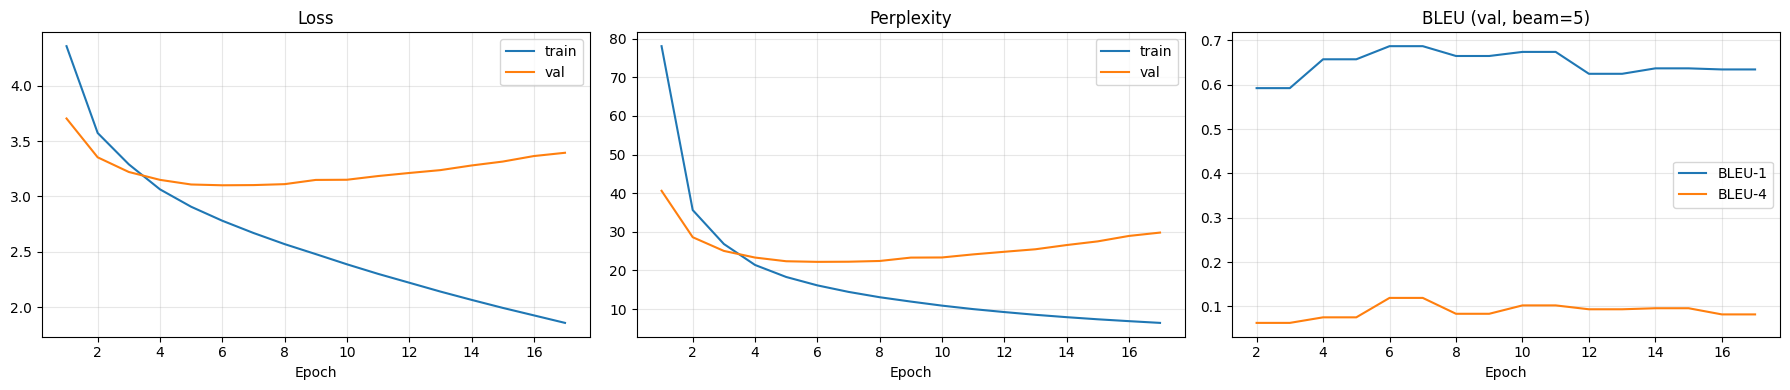

In [16]:
ep = range(1, len(train_losses)+1)
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

axes[0].plot(ep, train_losses, label="train"); axes[0].plot(ep, val_losses, label="val")
axes[0].set(title="Loss", xlabel="Epoch"); axes[0].legend(); axes[0].grid(alpha=.3)

axes[1].plot(ep, [math.exp(min(l,10)) for l in train_losses], label="train")
axes[1].plot(ep, [math.exp(min(l,10)) for l in val_losses],   label="val")
axes[1].set(title="Perplexity", xlabel="Epoch"); axes[1].legend(); axes[1].grid(alpha=.3)

axes[2].plot(ep, bleu1s, label="BLEU-1"); axes[2].plot(ep, bleu4s, label="BLEU-4")
axes[2].set(title=f"BLEU (val, beam={BEAM_WIDTH})", xlabel="Epoch"); axes[2].legend(); axes[2].grid(alpha=.3)

plt.tight_layout()
plt.savefig(MODEL_DIR / "curves.png", dpi=150)
plt.show()


## 17 · Save Final Artifacts

Saves the final weights, `config.json`, and vocab, and backs everything up to Drive.

In [17]:
import shutil

torch.save(_encoder.state_dict(), MODEL_DIR / "encoder_final.pth")
torch.save(_decoder.state_dict(), MODEL_DIR / "decoder_final.pth")

cfg = dict(
    encoder="efficientnet_b4_singlescale", proj_dim=PROJ_DIM,
    decoder="transformer", embed_size=EMBED_SIZE,
    n_heads=N_HEADS, n_layers=N_LAYERS, ffn_dim=FFN_DIM,
    dropout=DROPOUT, vocab_size=len(vocab), max_seq_len=MAX_SEQ_LEN,
    beam_width=BEAM_WIDTH, length_penalty=LENGTH_PENALTY,
    best_val_loss=best_val,
    final_bleu1=bleu1s[-1] if bleu1s else None,
    final_bleu4=bleu4s[-1] if bleu4s else None,
    n_gpus=N_GPUS, grad_accum_steps=GRAD_ACCUM_STEPS,
    label_smoothing=LABEL_SMOOTHING, weight_decay=WEIGHT_DECAY,
    best_bleu4=best_bleu4,
)
with open(MODEL_DIR / "config.json", "w") as f:
    json.dump(cfg, f, indent=2)

if DRIVE_DIR:
    for fname in ["encoder_final.pth", "decoder_final.pth", "vocab.pkl", "config.json"]:
        src = MODEL_DIR / fname
        if src.exists():
            shutil.copy(src, Path(DRIVE_DIR) / fname)
    print(f"All artifacts backed up to Drive: {DRIVE_DIR}")

print("Saved locally:")
for p in sorted(MODEL_DIR.iterdir()):
    print(f"  {p.name}  {p.stat().st_size/1024:.1f} KB")


Saved locally:
  config.json  0.5 KB
  curves.png  94.7 KB
  decoder_best.pth  42789.3 KB
  decoder_best_bleu.pth  42789.5 KB
  decoder_epoch05_periodic.pth  42789.9 KB
  decoder_epoch10_periodic.pth  42789.9 KB
  decoder_epoch15_periodic.pth  42789.9 KB
  decoder_final.pth  42789.3 KB
  encoder_best.pth  72884.4 KB
  encoder_best_bleu.pth  72888.1 KB
  encoder_epoch05_periodic.pth  72893.5 KB
  encoder_epoch10_periodic.pth  72893.5 KB
  encoder_epoch15_periodic.pth  72893.5 KB
  encoder_final.pth  72885.1 KB
  training_state.json  1.5 KB
  vocab.pkl  96.6 KB


## 18 · Inference Demo

Loads the **best-BLEU** checkpoint and captions validation images plus your own uploads, so you can inspect caption quality qualitatively (not just by BLEU).

Loading: encoder_best_bleu.pth


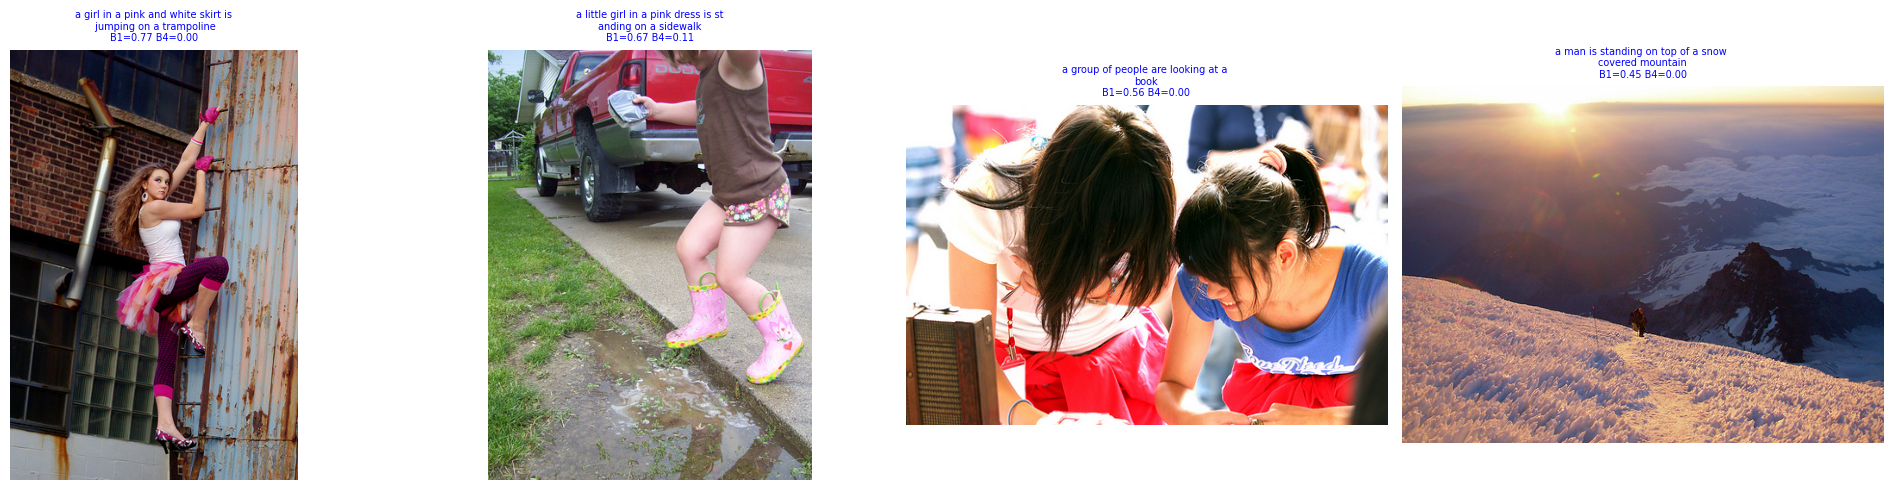

No custom images yet — add file paths to CUSTOM_IMAGE_PATHS above.
Upload widget ready — select image(s) then click 'Caption uploaded images'.


In [18]:
import io, base64
from IPython.display import display, clear_output, HTML
from pathlib import Path

# ── Load best checkpoint for inference ─────────────────────────────────────────
# WAS (original v9): always loaded encoder_best.pth (lowest val loss).
# NOW: prefer encoder_best_bleu.pth (highest BLEU-4) — better actual captions.
# Falls back to encoder_best.pth if BLEU checkpoint doesn't exist yet (first run).
_bleu_enc = MODEL_DIR / "encoder_best_bleu.pth"
_bleu_dec = MODEL_DIR / "decoder_best_bleu.pth"
_enc_ckpt = _bleu_enc if _bleu_enc.exists() else MODEL_DIR / "encoder_best.pth"
_dec_ckpt = _bleu_dec if _bleu_dec.exists() else MODEL_DIR / "decoder_best.pth"
print(f"Loading: {_enc_ckpt.name}")
_encoder.load_state_dict(torch.load(_enc_ckpt, map_location=DEVICE, weights_only=True))
_decoder.load_state_dict(torch.load(_dec_ckpt, map_location=DEVICE, weights_only=True))
_encoder.eval(); _decoder.eval()


def caption_image(img):
    t = val_transform(img.convert("RGB")).unsqueeze(0).to(DEVICE)
    with torch.no_grad(), torch.autocast(device_type=DEVICE.type, enabled=USE_AMP):
        f    = _encoder(t)
        toks = _decoder.generate_beam(f, vocab, BEAM_WIDTH, length_penalty=LENGTH_PENALTY)
    return toks


def show_captioned(img, cap_str, bleu_dict=None, title_extra=""):
    """Display a single PIL image with its generated caption."""
    fig, ax = plt.subplots(figsize=(6, 6))
    ax.imshow(img); ax.axis("off")
    label = "\n".join([cap_str[i:i+50] for i in range(0, len(cap_str), 50)])
    if bleu_dict:
        label += f"\nB1={bleu_dict['bleu1']:.2f}  B4={bleu_dict['bleu4']:.2f}"
    if title_extra:
        label += f"\n{title_extra}"
    ax.set_title(label, fontsize=9, color="blue")
    plt.tight_layout(); plt.show()


# ── 1. Sample from val set ─────────────────────────────────────────────────────
sample_imgs = val_df["image"].unique().tolist()
random.shuffle(sample_imgs)
sample_imgs = sample_imgs[:4]

fig, axes = plt.subplots(1, 4, figsize=(20, 5))
for ax, name in zip(axes, sample_imgs):
    img  = Image.open(IMG_DIR / name)
    toks = caption_image(img)
    refs = val_df[val_df["image"] == name]["caption"].tolist()
    bleu = corpus_bleu([toks], [[r.split() for r in refs]])
    cap_str = " ".join(toks)
    ax.imshow(img); ax.axis("off")
    ax.set_title(
        "\n".join([cap_str[i:i+35] for i in range(0, min(len(cap_str), 70), 35)])
        + f"\nB1={bleu['bleu1']:.2f} B4={bleu['bleu4']:.2f}",
        fontsize=7, color="blue",
    )
plt.tight_layout()
plt.savefig(MODEL_DIR / "samples.png", dpi=150)
plt.show()


# ── 2. Caption your own images by file path ────────────────────────────────────
# Add absolute paths here. Works on Colab, Kaggle, and local.
CUSTOM_IMAGE_PATHS = [
    # "/kaggle/input/<your-dataset>/example1.jpg",
    # "/content/my_photo.jpg",
    # "/content/drive/MyDrive/image_captioning/sample.jpg",
]

def caption_paths(paths):
    paths = [Path(p) for p in paths if Path(p).exists()]
    if not paths:
        print("No custom images yet — add file paths to CUSTOM_IMAGE_PATHS above.")
        return
    fig, axes = plt.subplots(1, len(paths), figsize=(6 * len(paths), 6))
    if len(paths) == 1:
        axes = [axes]
    for ax, p in zip(axes, paths):
        img     = Image.open(p)
        cap_str = " ".join(caption_image(img))
        ax.imshow(img); ax.axis("off")
        ax.set_title("\n".join([cap_str[i:i+50] for i in range(0, len(cap_str), 50)]),
                     fontsize=9, color="blue")
        print(f"{p.name}: {cap_str}")
    plt.tight_layout(); plt.show()

caption_paths(CUSTOM_IMAGE_PATHS)


# ── 3. Interactive upload — works on Colab AND Kaggle ─────────────────────────
# WAS: google.colab.files.upload() — Colab-only, and breaks with
#      "Upload widget is only available when the cell has been executed in the
#       current browser session" whenever the kernel restarts mid-session.
# NOW: ipywidgets.FileUpload — works on both Colab and Kaggle without needing
#      a fresh browser session. The widget renders once and stays active; bytes
#      are read directly from widget.value without any session dependency.
# WHY ipywidgets over colab.files:
#   - No "must re-execute cell" error after a kernel reconnect.
#   - Same code path on Colab and Kaggle (no IN_COLAB branch needed).
#   - Multiple files handled in one go; caption button re-runnable any time.

try:
    import ipywidgets as widgets

    _upload = widgets.FileUpload(
        accept="image/*",
        multiple=True,
        description="Upload images",
        layout=widgets.Layout(width="250px"),
    )
    _btn = widgets.Button(
        description="Caption uploaded images",
        button_style="primary",
        layout=widgets.Layout(width="220px"),
    )
    _out = widgets.Output()

    def _on_caption(_):
        _out.clear_output()
        with _out:
            # ipywidgets ≥ 8.0: .value is a dict {filename: {"content": bytes, ...}}
            # ipywidgets < 8.0:  .value is a tuple of dicts with "content" key
            items = _upload.value
            if isinstance(items, dict):
                entries = [(fname, meta["content"]) for fname, meta in items.items()]
            else:
                entries = [(meta["name"], meta["content"]) for meta in items]

            if not entries:
                print("No images uploaded yet — use the 'Upload images' button above.")
                return

            for fname, raw_bytes in entries:
                try:
                    img     = Image.open(io.BytesIO(raw_bytes)).convert("RGB")
                    cap_str = " ".join(caption_image(img))
                    print(f"{fname}: {cap_str}")
                    show_captioned(img, cap_str, title_extra=fname)
                except Exception as e:
                    print(f"  Could not process {fname}: {e}")

    _btn.on_click(_on_caption)
    print("Upload widget ready — select image(s) then click 'Caption uploaded images'.")
    display(widgets.VBox([_upload, _btn, _out]))

except ImportError:
    print("ipywidgets not found. Install it with:")
    print("  !pip install ipywidgets --quiet")
    print("Then re-run this cell.")
    print()
    print("Alternatively, add image paths to CUSTOM_IMAGE_PATHS above (section 2).")